# Course 2 Week 1: Autocorrect and Minimum Edit Distance

## Natural Language Processing with Probabilistic Models

This notebook provides a complete hands-on implementation of an autocorrect system using probability and minimum edit distance algorithms.

---

## 1. Setup and Imports

Setting up our environment for building an autocorrect system from scratch.

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter, defaultdict
import re
import string
from typing import List, Tuple, Dict, Set

# Set random seed for reproducibility
np.random.seed(42)

# Display settings
pd.set_option('display.max_columns', None)
plt.style.use('seaborn-v0_8-darkgrid')

print("All libraries imported successfully!")
print("Ready to build an autocorrect system!")

All libraries imported successfully!
Ready to build an autocorrect system!


## 2. Sample Text Corpus

Creating a corpus to calculate word probabilities.

In [3]:
# Sample corpus - simulating a real text dataset
corpus = """
i love natural language processing and machine learning
natural language processing is fascinating and exciting
machine learning helps us understand data better
i enjoy learning about neural networks and deep learning
deep learning models can process large amounts of data
language models are improving every year
autocorrect is a useful application of nlp
i use autocorrect on my phone every day
dear friend i hope you are doing well
happy birthday dear friend
the quick brown fox jumps over the lazy dog
i love programming in python and working on projects
data science is an exciting field with many opportunities
natural language understanding is a key challenge
i am happy to learn new things every day
"""

# Clean and tokenize
def process_data(text):
    """
    Process text data: lowercase, remove punctuation, tokenize
    """
    # Lowercase
    text = text.lower()

    # Remove punctuation
    text = text.translate(str.maketrans('', '', string.punctuation))

    # Tokenize
    words = text.split()

    return words

# Process corpus
words = process_data(corpus)

print(f"Corpus Statistics:")
print(f"Total words: {len(words)}")
print(f"Unique words: {len(set(words))}")
print(f"\nFirst 20 words:")
print(words[:20])

Corpus Statistics:
Total words: 116
Unique words: 76

First 20 words:
['i', 'love', 'natural', 'language', 'processing', 'and', 'machine', 'learning', 'natural', 'language', 'processing', 'is', 'fascinating', 'and', 'exciting', 'machine', 'learning', 'helps', 'us', 'understand']



## 3. Building Vocabulary with Word Counts

Creating frequency distribution for word probabilities.


In [4]:
# Count word frequencies
word_counts = Counter(words)

# Get vocabulary
vocab = sorted(word_counts.keys())

print(f"Vocabulary Statistics:")
print(f"Vocabulary size: {len(vocab)}")

# Most common words
print(f"\nTop 15 most frequent words:")
for word, count in word_counts.most_common(15):
    print(f"  '{word}': {count} occurrences")

# Create DataFrame for better visualization
freq_df = pd.DataFrame.from_dict(word_counts, orient='index', columns=['Count'])
freq_df = freq_df.sort_values('Count', ascending=False).head(20)

print(f"\nSample vocabulary:")
print(vocab[:15])

Vocabulary Statistics:
Vocabulary size: 76

Top 15 most frequent words:
  'i': 6 occurrences
  'learning': 5 occurrences
  'language': 4 occurrences
  'and': 4 occurrences
  'is': 4 occurrences
  'natural': 3 occurrences
  'data': 3 occurrences
  'every': 3 occurrences
  'love': 2 occurrences
  'processing': 2 occurrences
  'machine': 2 occurrences
  'exciting': 2 occurrences
  'deep': 2 occurrences
  'models': 2 occurrences
  'of': 2 occurrences

Sample vocabulary:
['a', 'about', 'am', 'amounts', 'an', 'and', 'application', 'are', 'autocorrect', 'better', 'birthday', 'brown', 'can', 'challenge', 'data']


### Visualize Word Frequencies


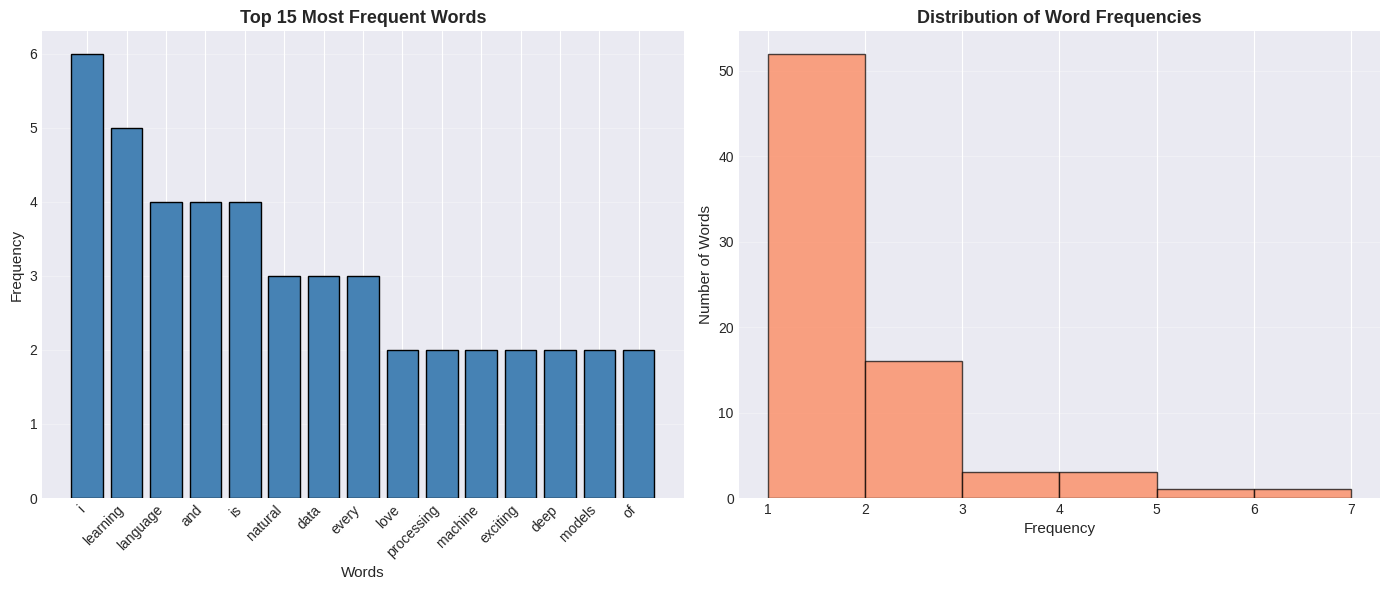


Frequency Statistics:
Max frequency: 6
Min frequency: 1
Average frequency: 1.53


In [5]:
# Plot word frequency distribution
plt.figure(figsize=(14, 6))

# Bar plot of top 15 words
plt.subplot(1, 2, 1)
top_words = word_counts.most_common(15)
words_list, counts_list = zip(*top_words)
plt.bar(range(len(words_list)), counts_list, color='steelblue', edgecolor='black')
plt.xticks(range(len(words_list)), words_list, rotation=45, ha='right')
plt.xlabel('Words', fontsize=11)
plt.ylabel('Frequency', fontsize=11)
plt.title('Top 15 Most Frequent Words', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

# Histogram of frequency distribution
plt.subplot(1, 2, 2)
frequency_values = list(word_counts.values())
plt.hist(frequency_values, bins=range(1, max(frequency_values)+2),
         color='coral', edgecolor='black', alpha=0.7)
plt.xlabel('Frequency', fontsize=11)
plt.ylabel('Number of Words', fontsize=11)
plt.title('Distribution of Word Frequencies', fontsize=13, fontweight='bold')
plt.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('word_frequencies.png', dpi=300, bbox_inches='tight')
plt.show()

print(f"\nFrequency Statistics:")
print(f"Max frequency: {max(frequency_values)}")
print(f"Min frequency: {min(frequency_values)}")
print(f"Average frequency: {np.mean(frequency_values):.2f}")

## 4. Calculate Word Probabilities

Computing probability for each word based on frequency.

In [6]:
def get_probs(word_counts):
    """
    Calculate probability for each word

    P(word) = count(word) / total_words
    """
    total_words = sum(word_counts.values())
    probs = {word: count / total_words for word, count in word_counts.items()}
    return probs

# Calculate probabilities
probs = get_probs(word_counts)

print("Word Probabilities:")
print(f"Total word count: {sum(word_counts.values())}")

# Show probabilities for top words
print(f"\nTop 10 words with probabilities:")
sorted_probs = sorted(probs.items(), key=lambda x: x[1], reverse=True)
for word, prob in sorted_probs[:10]:
    count = word_counts[word]
    print(f"  '{word}': P = {prob:.4f} (count = {count})")

# Verify probabilities sum to 1
total_prob = sum(probs.values())
print(f"\nSum of all probabilities: {total_prob:.6f} (should be 1.0)")

# Create probability DataFrame
prob_df = pd.DataFrame({
    'Word': list(probs.keys()),
    'Probability': list(probs.values()),
    'Count': [word_counts[w] for w in probs.keys()]
})
prob_df = prob_df.sort_values('Probability', ascending=False).head(10)
print(f"\nProbability Table (Top 10):")
print(prob_df.to_string(index=False))


Word Probabilities:
Total word count: 116

Top 10 words with probabilities:
  'i': P = 0.0517 (count = 6)
  'learning': P = 0.0431 (count = 5)
  'language': P = 0.0345 (count = 4)
  'and': P = 0.0345 (count = 4)
  'is': P = 0.0345 (count = 4)
  'natural': P = 0.0259 (count = 3)
  'data': P = 0.0259 (count = 3)
  'every': P = 0.0259 (count = 3)
  'love': P = 0.0172 (count = 2)
  'processing': P = 0.0172 (count = 2)

Sum of all probabilities: 1.000000 (should be 1.0)

Probability Table (Top 10):
    Word  Probability  Count
       i     0.051724      6
learning     0.043103      5
     and     0.034483      4
language     0.034483      4
      is     0.034483      4
 natural     0.025862      3
   every     0.025862      3
    data     0.025862      3
 machine     0.017241      2
exciting     0.017241      2


## 5. String Manipulation - Edit Operations

Understanding the four types of edit operations.


In [7]:
def delete_letter(word, verbose=False):
    """
    Delete one letter at each position

    Example: 'hat' → ['at', 'ht', 'ha']
    """
    splits = [(word[:i], word[i:]) for i in range(len(word) + 1)]
    deletes = [L + R[1:] for L, R in splits if R]

    if verbose:
        print(f"Input word: '{word}'")
        print(f"Splits: {splits[:5]}...")  # Show first 5
        print(f"Deletes: {deletes}")

    return deletes

In [8]:
def insert_letter(word, verbose=False):
    """
    Insert any letter a-z at each position

    Example: 'at' → ['aat', 'bat', ..., 'zat', 'aat', 'abt', ...]
    """
    letters = 'abcdefghijklmnopqrstuvwxyz'
    splits = [(word[:i], word[i:]) for i in range(len(word) + 1)]
    inserts = [L + c + R for L, R in splits for c in letters]

    if verbose:
        print(f"Input word: '{word}'")
        print(f"Number of possible insertions: {len(inserts)}")
        print(f"Sample inserts: {inserts[:10]}")

    return inserts

In [9]:
def replace_letter(word, verbose=False):
    """
    Replace each letter with any other letter a-z

    Example: 'hat' → ['aat', 'bat', ..., 'hzt', 'haa', 'hab', ...]
    """
    letters = 'abcdefghijklmnopqrstuvwxyz'
    splits = [(word[:i], word[i:]) for i in range(len(word) + 1)]
    replaces = [L + c + R[1:] for L, R in splits if R for c in letters if c != R[0]]

    if verbose:
        print(f"Input word: '{word}'")
        print(f"Number of possible replacements: {len(replaces)}")
        print(f"Sample replaces: {replaces[:10]}")

    return replaces

In [10]:
def switch_letter(word, verbose=False):
    """
    Switch adjacent letters

    Example: 'hat' → ['aht', 'hta']
    """
    splits = [(word[:i], word[i:]) for i in range(len(word) + 1)]
    switches = [L + R[1] + R[0] + R[2:] for L, R in splits if len(R) > 1]

    if verbose:
        print(f"Input word: '{word}'")
        print(f"Switches: {switches}")

    return switches

In [12]:
# Test all operations
test_word = "dear"
print("Edit Operations Test:")

print(f"\n1. DELETE operations on '{test_word}':")
deletes = delete_letter(test_word, verbose=True)

print(f"\n2. INSERT operations on '{test_word}':")
inserts = insert_letter(test_word, verbose=True)

print(f"\n3. REPLACE operations on '{test_word}':")
replaces = replace_letter(test_word, verbose=True)

print(f"\n4. SWITCH operations on '{test_word}':")
switches = switch_letter(test_word, verbose=True)

print(f"\n\nSummary for '{test_word}':")
print(f"  Deletes: {len(deletes)} variants")
print(f"  Inserts: {len(inserts)} variants")
print(f"  Replaces: {len(replaces)} variants")
print(f"  Switches: {len(switches)} variants")
print(f"  Total 1-edit candidates: {len(deletes) + len(inserts) + len(replaces) + len(switches)}")

Edit Operations Test:

1. DELETE operations on 'dear':
Input word: 'dear'
Splits: [('', 'dear'), ('d', 'ear'), ('de', 'ar'), ('dea', 'r'), ('dear', '')]...
Deletes: ['ear', 'dar', 'der', 'dea']

2. INSERT operations on 'dear':
Input word: 'dear'
Number of possible insertions: 130
Sample inserts: ['adear', 'bdear', 'cdear', 'ddear', 'edear', 'fdear', 'gdear', 'hdear', 'idear', 'jdear']

3. REPLACE operations on 'dear':
Input word: 'dear'
Number of possible replacements: 100
Sample replaces: ['aear', 'bear', 'cear', 'eear', 'fear', 'gear', 'hear', 'iear', 'jear', 'kear']

4. SWITCH operations on 'dear':
Input word: 'dear'
Switches: ['edar', 'daer', 'dera']


Summary for 'dear':
  Deletes: 4 variants
  Inserts: 130 variants
  Replaces: 100 variants
  Switches: 3 variants
  Total 1-edit candidates: 237


## 6. Generate Edit Distance 1 Candidates

Creating all possible words one edit away from the misspelled word.


In [14]:
def edit_one_letter(word, allow_switches=True):
    """
    Generate all possible words that are one edit away

    Returns a set of all edit-1 variants
    """
    edit_set = set()

    # Add all types of edits
    edit_set.update(delete_letter(word))
    edit_set.update(insert_letter(word))
    edit_set.update(replace_letter(word))

    if allow_switches:
        edit_set.update(switch_letter(word))

    return edit_set

# Test edit_one_letter
test_word = "deah"
edit1_set = edit_one_letter(test_word)

print(f"Edit-1 Candidates for '{test_word}':")
print(f"Total candidates: {len(edit1_set)}")

# Sample some candidates
sample_candidates = sorted(list(edit1_set))[:30]
print(f"\nFirst 30 candidates (alphabetically):")
for i, candidate in enumerate(sample_candidates, 1):
    print(f"{i:2d}. {candidate}", end="  ")
    if i % 5 == 0:
        print()

# Check which are real words (in our vocabulary)
real_words_edit1 = [w for w in edit1_set if w in vocab]
print(f"\n\nReal words (in vocabulary) from edit-1:")
print(real_words_edit1 if real_words_edit1 else "None found in this vocabulary")


Edit-1 Candidates for 'deah':
Total candidates: 233

First 30 candidates (alphabetically):
 1. adeah   2. aeah   3. bdeah   4. beah   5. cdeah  
 6. ceah   7. daah   8. daeah   9. daeh  10. dah  
11. dbah  12. dbeah  13. dcah  14. dceah  15. ddah  
16. ddeah  17. dea  18. deaa  19. deaah  20. deab  
21. deabh  22. deac  23. deach  24. dead  25. deadh  
26. deae  27. deaeh  28. deaf  29. deafh  30. deag  


Real words (in vocabulary) from edit-1:
['dear']


## 7. Generate Edit Distance 2 Candidates

Creating all possible words two edits away.


In [16]:
def edit_two_letters(word, allow_switches=True):
    """
    Generate all possible words that are two edits away

    Apply edit_one_letter twice
    """
    edit_two_set = set()

    # First get all edit-1 variants
    edit_one_variants = edit_one_letter(word, allow_switches)

    # For each edit-1 variant, get all edit-1 variants again
    for variant in edit_one_variants:
        edit_two_set.update(edit_one_letter(variant, allow_switches))

    return edit_two_set

# Test edit_two_letters
test_word = "deah"
edit2_set = edit_two_letters(test_word)

print(f"Edit-2 Candidates for '{test_word}':")
print(f"Edit-1 candidates: {len(edit_one_letter(test_word))}")
print(f"Edit-2 candidates: {len(edit2_set)}")

# This is a huge number! Let's see how many are real words
real_words_edit2 = [w for w in edit2_set if w in vocab]
print(f"\nReal words (in vocabulary) from edit-2: {len(real_words_edit2)}")
print(f"Examples: {real_words_edit2[:15]}")

print(f"\nKey Insight:")
print(f"  Edit-1 generates ~hundreds of candidates")
print(f"  Edit-2 generates ~tens of thousands of candidates")
print(f"  Most are not real words!")
print(f"  We need to filter and rank by probability")

Edit-2 Candidates for 'deah':
Edit-1 candidates: 233
Edit-2 candidates: 24254

Real words (in vocabulary) from edit-2: 4
Examples: ['dear', 'year', 'deep', 'day']

Key Insight:
  Edit-1 generates ~hundreds of candidates
  Edit-2 generates ~tens of thousands of candidates
  Most are not real words!
  We need to filter and rank by probability



## 8. Filter Candidates by Vocabulary

Keeping only candidates that are real words.

In [18]:
def get_corrections(word, probs, vocab, n=2, verbose=False):
    """
    Get word corrections ranked by probability

    Args:
        word: misspelled word
        probs: word probability dictionary
        vocab: set of valid words
        n: edit distance to consider (1 or 2)

    Returns:
        List of (correction, probability) sorted by probability
    """
    # Generate candidates
    if n == 1:
        candidates = edit_one_letter(word)
    elif n == 2:
        candidates = edit_two_letters(word)
    else:
        candidates = {word}

    # Filter to real words
    valid_candidates = [w for w in candidates if w in vocab]

    # Get probabilities
    candidate_probs = [(w, probs.get(w, 0)) for w in valid_candidates]

    # Sort by probability (descending)
    candidate_probs.sort(key=lambda x: x[1], reverse=True)

    if verbose:
        print(f"Word: '{word}'")
        print(f"Total candidates (edit-{n}): {len(candidates)}")
        print(f"Valid candidates: {len(valid_candidates)}")
        print(f"Top corrections:")
        for w, p in candidate_probs[:10]:
            print(f"  '{w}': P = {p:.6f}")

    return candidate_probs

# Test with "deah"
test_word = "deah"

print("Finding Corrections:")

# Edit distance 1
print("\n1. Edit Distance 1 corrections:")
corrections_1 = get_corrections(test_word, probs, vocab, n=1, verbose=True)

# Edit distance 2
print("\n2. Edit Distance 2 corrections:")
corrections_2 = get_corrections(test_word, probs, vocab, n=2, verbose=True)


Finding Corrections:

1. Edit Distance 1 corrections:
Word: 'deah'
Total candidates (edit-1): 233
Valid candidates: 1
Top corrections:
  'dear': P = 0.017241

2. Edit Distance 2 corrections:
Word: 'deah'
Total candidates (edit-2): 24254
Valid candidates: 4
Top corrections:
  'dear': P = 0.017241
  'deep': P = 0.017241
  'day': P = 0.017241
  'year': P = 0.008621


## 9. Complete Autocorrect Function

Building the full autocorrect system that combines all steps.


In [20]:
def autocorrect(word, probs, vocab, n=2):
    """
    Complete autocorrect function

    Steps:
    1. Check if word is already correct (in vocabulary)
    2. Try edit distance 1 corrections
    3. If none found, try edit distance 2 corrections
    4. Return most probable correction

    Args:
        word: potentially misspelled word
        probs: word probability dictionary
        vocab: set of valid words
        n: maximum edit distance to consider

    Returns:
        Best correction (or original word if no correction found)
    """
    # If word is already in vocabulary, return it
    if word in vocab:
        return word

    # Try edit distance 1
    corrections_1 = get_corrections(word, probs, vocab, n=1)
    if corrections_1:
        return corrections_1[0][0]  # Return most probable

    # Try edit distance 2 if n >= 2
    if n >= 2:
        corrections_2 = get_corrections(word, probs, vocab, n=2)
        if corrections_2:
            return corrections_2[0][0]

    # No correction found, return original
    return word

# Convert vocab to set for faster lookup
vocab_set = set(vocab)

# Test autocorrect with various misspellings
test_cases = [
    "deah",      # should correct to "dear" or similar
    "learing",   # should correct to "learning"
    "languae",   # should correct to "language"
    "procesing", # should correct to "processing"
    "machin",    # should correct to "machine"
    "dta",       # should correct to "data"
    "deep",      # already correct
    "python",    # already correct (if in vocab)
]

print("Autocorrect Tests:")

for test_word in test_cases:
    correction = autocorrect(test_word, probs, vocab_set, n=2)
    status = "✓ Already correct" if test_word == correction and test_word in vocab_set else "→ Corrected"

    if test_word != correction:
        # Get probability of correction
        prob = probs.get(correction, 0)
        print(f"{status}: '{test_word}' → '{correction}' (P = {prob:.6f})")
    else:
        if test_word in vocab_set:
            prob = probs.get(test_word, 0)
            print(f"{status}: '{test_word}' (P = {prob:.6f})")
        else:
            print(f"✗ No correction: '{test_word}' (not in vocabulary)")


Autocorrect Tests:
→ Corrected: 'deah' → 'dear' (P = 0.017241)
→ Corrected: 'learing' → 'learning' (P = 0.043103)
→ Corrected: 'languae' → 'language' (P = 0.034483)
→ Corrected: 'procesing' → 'processing' (P = 0.017241)
→ Corrected: 'machin' → 'machine' (P = 0.017241)
→ Corrected: 'dta' → 'data' (P = 0.025862)
✓ Already correct: 'deep' (P = 0.017241)
✓ Already correct: 'python' (P = 0.008621)


## 10. Minimum Edit Distance - Introduction

Understanding the concept and importance of edit distance.

In [23]:
# Visual representation of edit operations
def visualize_edit_operations():
    """
    Show examples of each edit operation type
    """
    print("Edit Operations Overview:")

    examples = [
        ("INSERT", "cat", "cats", "Insert 's' at end"),
        ("DELETE", "cats", "cat", "Delete 's' from end"),
        ("REPLACE", "cat", "bat", "Replace 'c' with 'b'"),
        ("SWITCH", "act", "cat", "Switch 'a' and 'c'"),
    ]

    for op, source, target, desc in examples:
        print(f"\n{op}:")
        print(f"  {source} → {target}")
        print(f"  {desc}")

visualize_edit_operations()

# Examples of edit distances
print("\n\nEdit Distance Examples:")

examples = [
    ("cat", "hat", 1, "1 replacement: c→h"),
    ("cat", "cats", 1, "1 insertion: +s"),
    ("cat", "at", 1, "1 deletion: c"),
    ("cat", "dog", 3, "3 replacements: c→d, a→o, t→g"),
    ("play", "stay", 2, "2 replacements: p→s, l→t"),
]

for source, target, dist, desc in examples:
    print(f"'{source}' → '{target}':")
    print(f"  Edit distance: {dist}")
    print(f"  Operations: {desc}\n")


Edit Operations Overview:

INSERT:
  cat → cats
  Insert 's' at end

DELETE:
  cats → cat
  Delete 's' from end

REPLACE:
  cat → bat
  Replace 'c' with 'b'

SWITCH:
  act → cat
  Switch 'a' and 'c'


Edit Distance Examples:
'cat' → 'hat':
  Edit distance: 1
  Operations: 1 replacement: c→h

'cat' → 'cats':
  Edit distance: 1
  Operations: 1 insertion: +s

'cat' → 'at':
  Edit distance: 1
  Operations: 1 deletion: c

'cat' → 'dog':
  Edit distance: 3
  Operations: 3 replacements: c→d, a→o, t→g

'play' → 'stay':
  Edit distance: 2
  Operations: 2 replacements: p→s, l→t



## 11. Edit Distance Costs

Defining cost structure for different operations.

In [24]:
# Standard Levenshtein costs
print("Edit Operation Costs:")

costs = {
    'Insert': 1,
    'Delete': 1,
    'Replace': 2,  # More expensive than insert/delete
}

print("\nStandard Levenshtein Distance Costs:")
for operation, cost in costs.items():
    print(f"  {operation}: {cost}")

print("\nWhy Replace costs 2:")
print("  Replace = Delete + Insert")
print("  Example: 'cat' → 'hat'")
print("    Option 1: Replace 'c' with 'h' = cost 2")
print("    Option 2: Delete 'c' + Insert 'h' = cost 1+1 = 2")
print("  Both give same total cost!")

# Show cost calculation example
def calculate_cost_example():
    """
    Calculate total cost for a sequence of operations
    """
    print("\n\nExample: 'play' → 'stay'")

    operations = [
        ("Replace 'p' with 's'", 2),
        ("Replace 'l' with 't'", 2),
        ("Keep 'a'", 0),
        ("Keep 'y'", 0),
    ]

    total = 0
    for op, cost in operations:
        print(f"{op}: cost = {cost}")
        total += cost

    print(f"\nTotal cost (Edit Distance): {total}")

calculate_cost_example()


Edit Operation Costs:

Standard Levenshtein Distance Costs:
  Insert: 1
  Delete: 1
  Replace: 2

Why Replace costs 2:
  Replace = Delete + Insert
  Example: 'cat' → 'hat'
    Option 1: Replace 'c' with 'h' = cost 2
    Option 2: Delete 'c' + Insert 'h' = cost 1+1 = 2
  Both give same total cost!


Example: 'play' → 'stay'
Replace 'p' with 's': cost = 2
Replace 'l' with 't': cost = 2
Keep 'a': cost = 0
Keep 'y': cost = 0

Total cost (Edit Distance): 4



## 12. Minimum Edit Distance - Brute Force (Conceptual)

Understanding why we need dynamic programming.

In [25]:
def edit_distance_recursive(source, target, i, j, memo=None):
    """
    Recursive calculation of edit distance (with memoization)
    This demonstrates the concept - not the efficient approach!

    Args:
        source, target: strings to compare
        i, j: current positions in source and target
        memo: dictionary for memoization
    """
    if memo is None:
        memo = {}

    # Base cases
    if i == 0:
        return j  # Need j insertions
    if j == 0:
        return i  # Need i deletions

    # Check memo
    if (i, j) in memo:
        return memo[(i, j)]

    # If characters match, no operation needed
    if source[i-1] == target[j-1]:
        result = edit_distance_recursive(source, target, i-1, j-1, memo)
    else:
        # Three options: insert, delete, replace
        insert_cost = edit_distance_recursive(source, target, i, j-1, memo) + 1
        delete_cost = edit_distance_recursive(source, target, i-1, j, memo) + 1
        replace_cost = edit_distance_recursive(source, target, i-1, j-1, memo) + 2

        result = min(insert_cost, delete_cost, replace_cost)

    memo[(i, j)] = result
    return result

# Test recursive version
test_pairs = [
    ("cat", "hat"),
    ("play", "stay"),
    ("dear", "deer"),
]

print("Recursive Edit Distance (with Memoization):")

for source, target in test_pairs:
    distance = edit_distance_recursive(source, target, len(source), len(target))
    print(f"'{source}' → '{target}': distance = {distance}")

print("\nProblem with Pure Recursion (without memoization):")
print("  • Recalculates same subproblems multiple times")
print("  • Exponential time complexity: O(3^(m+n))")
print("  • Impractical for long strings")
print("\nSolution: Dynamic Programming!")
print("  • Calculate each subproblem once")
print("  • Store results in table")
print("  • Time complexity: O(m × n)")


Recursive Edit Distance (with Memoization):
'cat' → 'hat': distance = 2
'play' → 'stay': distance = 4
'dear' → 'deer': distance = 2

Problem with Pure Recursion (without memoization):
  • Recalculates same subproblems multiple times
  • Exponential time complexity: O(3^(m+n))
  • Impractical for long strings

Solution: Dynamic Programming!
  • Calculate each subproblem once
  • Store results in table
  • Time complexity: O(m × n)


## 13. Dynamic Programming Table - Base Cases

Setting up the DP table with initial values.

In [26]:
def initialize_dp_table(source, target, verbose=True):
    """
    Initialize DP table with base cases

    Table dimensions: (len(source)+1) × (len(target)+1)
    """
    m, n = len(source), len(target)

    # Create table with zeros
    D = [[0] * (n + 1) for _ in range(m + 1)]

    # Base case: transform empty string to target
    for j in range(n + 1):
        D[0][j] = j  # j insertions needed

    # Base case: transform source to empty string
    for i in range(m + 1):
        D[i][0] = i  # i deletions needed

    if verbose:
        print(f"Initialized DP Table for '{source}' → '{target}':")
        print(f"Table size: {m+1} × {n+1}")
        print("\nBase cases filled:")
        print_dp_table(D, source, target)

    return D

def print_dp_table(D, source, target):
    """
    Pretty print the DP table with row/column labels
    """
    m, n = len(source), len(target)

    # Header
    print("     ", end="")
    print("  #", end="")
    for char in target:
        print(f"  {char}", end="")
    print()

    # Rows
    for i in range(m + 1):
        if i == 0:
            print("  #", end="")
        else:
            print(f"  {source[i-1]}", end="")

        for j in range(n + 1):
            print(f" {D[i][j]:2d}", end="")
        print()

# Test initialization
test_source = "play"
test_target = "stay"

print("DP Table Initialization:")
D = initialize_dp_table(test_source, test_target)


DP Table Initialization:
Initialized DP Table for 'play' → 'stay':
Table size: 5 × 5

Base cases filled:
       #  s  t  a  y
  #  0  1  2  3  4
  p  1  0  0  0  0
  l  2  0  0  0  0
  a  3  0  0  0  0
  y  4  0  0  0  0


## 14. Dynamic Programming - Fill the Table

Computing edit distance using the DP recurrence relation.

In [27]:
def min_edit_distance(source, target, verbose=True):
    """
    Calculate minimum edit distance using dynamic programming

    Recurrence relation:
    D[i][j] = min(
        D[i-1][j] + 1,      # delete
        D[i][j-1] + 1,      # insert
        D[i-1][j-1] + cost  # replace (cost=0 if match, 2 if different)
    )
    """
    m, n = len(source), len(target)

    # Initialize table
    D = [[0] * (n + 1) for _ in range(m + 1)]

    # Base cases
    for i in range(m + 1):
        D[i][0] = i
    for j in range(n + 1):
        D[0][j] = j

    # Fill the table
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            # Cost of replace (0 if match, 2 if different)
            replace_cost = 0 if source[i-1] == target[j-1] else 2

            # Three options
            delete = D[i-1][j] + 1
            insert = D[i][j-1] + 1
            replace = D[i-1][j-1] + replace_cost

            # Take minimum
            D[i][j] = min(delete, insert, replace)

    if verbose:
        print(f"\nComplete DP Table for '{source}' → '{target}':")
        print_dp_table(D, source, target)
        print(f"\nMinimum Edit Distance: {D[m][n]}")

    return D[m][n], D

# Test with examples
test_cases = [
    ("play", "stay"),
    ("cat", "hat"),
    ("dear", "deer"),
]

print("Minimum Edit Distance Calculation:")

for source, target in test_cases:
    print(f"\n{'='*60}")
    distance, table = min_edit_distance(source, target, verbose=True)


Minimum Edit Distance Calculation:


Complete DP Table for 'play' → 'stay':
       #  s  t  a  y
  #  0  1  2  3  4
  p  1  2  3  4  5
  l  2  3  4  5  6
  a  3  4  5  4  5
  y  4  5  6  5  4

Minimum Edit Distance: 4


Complete DP Table for 'cat' → 'hat':
       #  h  a  t
  #  0  1  2  3
  c  1  2  3  4
  a  2  3  2  3
  t  3  4  3  2

Minimum Edit Distance: 2


Complete DP Table for 'dear' → 'deer':
       #  d  e  e  r
  #  0  1  2  3  4
  d  1  0  1  2  3
  e  2  1  0  1  2
  a  3  2  1  2  3
  r  4  3  2  3  2

Minimum Edit Distance: 2


### Step-by-Step Example

In [31]:
def min_edit_distance_step_by_step(source, target):
    """
    Show step-by-step calculation for educational purposes
    """
    m, n = len(source), len(target)
    D = [[0] * (n + 1) for _ in range(m + 1)]

    # Base cases
    for i in range(m + 1):
        D[i][0] = i
    for j in range(n + 1):
        D[0][j] = j

    print(f"Computing edit distance: '{source}' → '{target}'")

    # Fill table with explanations
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            char_s = source[i-1]
            char_t = target[j-1]

            replace_cost = 0 if char_s == char_t else 2

            delete = D[i-1][j] + 1
            insert = D[i][j-1] + 1
            replace = D[i-1][j-1] + replace_cost

            D[i][j] = min(delete, insert, replace)

            # Print calculation for this cell
            print(f"\nCell D[{i}][{j}] ('{char_s}' vs '{char_t}'):")
            print(f"  Delete:  D[{i-1}][{j}] + 1 = {D[i-1][j]} + 1 = {delete}")
            print(f"  Insert:  D[{i}][{j-1}] + 1 = {D[i][j-1]} + 1 = {insert}")
            print(f"  Replace: D[{i-1}][{j-1}] + {replace_cost} = {D[i-1][j-1]} + {replace_cost} = {replace}")
            print(f"  → Minimum: {D[i][j]}")

    print("\nFinal Table:")
    print_dp_table(D, source, target)

    return D[m][n]

# Run step-by-step for a simple example
print("\nDetailed Step-by-Step Example:")
distance = min_edit_distance_step_by_step("cat", "hat")



Detailed Step-by-Step Example:
Computing edit distance: 'cat' → 'hat'

Cell D[1][1] ('c' vs 'h'):
  Delete:  D[0][1] + 1 = 1 + 1 = 2
  Insert:  D[1][0] + 1 = 1 + 1 = 2
  Replace: D[0][0] + 2 = 0 + 2 = 2
  → Minimum: 2

Cell D[1][2] ('c' vs 'a'):
  Delete:  D[0][2] + 1 = 2 + 1 = 3
  Insert:  D[1][1] + 1 = 2 + 1 = 3
  Replace: D[0][1] + 2 = 1 + 2 = 3
  → Minimum: 3

Cell D[1][3] ('c' vs 't'):
  Delete:  D[0][3] + 1 = 3 + 1 = 4
  Insert:  D[1][2] + 1 = 3 + 1 = 4
  Replace: D[0][2] + 2 = 2 + 2 = 4
  → Minimum: 4

Cell D[2][1] ('a' vs 'h'):
  Delete:  D[1][1] + 1 = 2 + 1 = 3
  Insert:  D[2][0] + 1 = 2 + 1 = 3
  Replace: D[1][0] + 2 = 1 + 2 = 3
  → Minimum: 3

Cell D[2][2] ('a' vs 'a'):
  Delete:  D[1][2] + 1 = 3 + 1 = 4
  Insert:  D[2][1] + 1 = 3 + 1 = 4
  Replace: D[1][1] + 0 = 2 + 0 = 2
  → Minimum: 2

Cell D[2][3] ('a' vs 't'):
  Delete:  D[1][3] + 1 = 4 + 1 = 5
  Insert:  D[2][2] + 1 = 2 + 1 = 3
  Replace: D[1][2] + 2 = 3 + 2 = 5
  → Minimum: 3

Cell D[3][1] ('t' vs 'h'):
  Delete:  D[

## 15. Backtracing - Reconstructing Edit Path

Finding which operations were used to achieve minimum distance.


In [32]:
def min_edit_distance_with_backtrace(source, target):
    """
    Calculate minimum edit distance AND track the path taken

    Returns:
        distance: minimum edit distance
        path: list of operations taken
    """
    m, n = len(source), len(target)

    # Initialize DP table and backtrace table
    D = [[0] * (n + 1) for _ in range(m + 1)]
    backtrace = [[None] * (n + 1) for _ in range(m + 1)]

    # Base cases
    for i in range(m + 1):
        D[i][0] = i
        backtrace[i][0] = 'DELETE' if i > 0 else None

    for j in range(n + 1):
        D[0][j] = j
        backtrace[0][j] = 'INSERT' if j > 0 else None

    # Fill tables
    for i in range(1, m + 1):
        for j in range(1, n + 1):
            replace_cost = 0 if source[i-1] == target[j-1] else 2

            delete = D[i-1][j] + 1
            insert = D[i][j-1] + 1
            replace = D[i-1][j-1] + replace_cost

            # Choose minimum and track operation
            if delete <= insert and delete <= replace:
                D[i][j] = delete
                backtrace[i][j] = 'DELETE'
            elif insert <= replace:
                D[i][j] = insert
                backtrace[i][j] = 'INSERT'
            else:
                D[i][j] = replace
                backtrace[i][j] = 'MATCH' if replace_cost == 0 else 'REPLACE'

    # Reconstruct path
    path = []
    i, j = m, n

    while i > 0 or j > 0:
        operation = backtrace[i][j]

        if operation == 'DELETE':
            path.append(f"Delete '{source[i-1]}' at position {i-1}")
            i -= 1
        elif operation == 'INSERT':
            path.append(f"Insert '{target[j-1]}' at position {i}")
            j -= 1
        elif operation == 'REPLACE':
            path.append(f"Replace '{source[i-1]}' with '{target[j-1]}' at position {i-1}")
            i -= 1
            j -= 1
        elif operation == 'MATCH':
            path.append(f"Keep '{source[i-1]}' at position {i-1}")
            i -= 1
            j -= 1

    path.reverse()

    return D[m][n], path, backtrace

# Test backtracing
test_cases = [
    ("play", "stay"),
    ("dear", "deer"),
]

print("Edit Distance with Backtrace:")

for source, target in test_cases:
    print(f"\nTransforming '{source}' → '{target}':")
    distance, path, backtrace_table = min_edit_distance_with_backtrace(source, target)

    print(f"Minimum edit distance: {distance}")
    print(f"\nOperations sequence:")
    for i, operation in enumerate(path, 1):
        print(f"  {i}. {operation}")


Edit Distance with Backtrace:

Transforming 'play' → 'stay':
Minimum edit distance: 4

Operations sequence:
  1. Insert 's' at position 0
  2. Insert 't' at position 0
  3. Delete 'p' at position 0
  4. Delete 'l' at position 1
  5. Keep 'a' at position 2
  6. Keep 'y' at position 3

Transforming 'dear' → 'deer':
Minimum edit distance: 2

Operations sequence:
  1. Keep 'd' at position 0
  2. Keep 'e' at position 1
  3. Insert 'e' at position 2
  4. Delete 'a' at position 2
  5. Keep 'r' at position 3


### Visualize Backtrace Path


In [33]:
def visualize_backtrace_path(source, target):
    """
    Visual representation of the backtrace path through the DP table
    """
    m, n = len(source), len(target)
    distance, path, backtrace = min_edit_distance_with_backtrace(source, target)

    # Create visual markers
    D = [[0] * (n + 1) for _ in range(m + 1)]
    for i in range(m + 1):
        D[i][0] = i
    for j in range(n + 1):
        D[0][j] = j

    for i in range(1, m + 1):
        for j in range(1, n + 1):
            replace_cost = 0 if source[i-1] == target[j-1] else 2
            delete = D[i-1][j] + 1
            insert = D[i][j-1] + 1
            replace = D[i-1][j-1] + replace_cost
            D[i][j] = min(delete, insert, replace)

    print(f"\nBacktrace Path Visualization for '{source}' → '{target}':")

    # Print table with backtrace arrows
    print("     ", end="")
    print("  #", end="")
    for char in target:
        print(f"  {char}", end="")
    print()

    for i in range(m + 1):
        if i == 0:
            print("  #", end="")
        else:
            print(f"  {source[i-1]}", end="")

        for j in range(n + 1):
            arrow = ""
            if backtrace[i][j] == 'DELETE':
                arrow = "↓"
            elif backtrace[i][j] == 'INSERT':
                arrow = "→"
            elif backtrace[i][j] == 'REPLACE' or backtrace[i][j] == 'MATCH':
                arrow = "↘"

            print(f"{D[i][j]:2d}{arrow}", end="")
        print()

    print("\nLegend:")
    print("  ↓ = DELETE (from above)")
    print("  → = INSERT (from left)")
    print("  ↘ = REPLACE or MATCH (from diagonal)")

# Visualize examples
for source, target in [("play", "stay")]:
    visualize_backtrace_path(source, target)



Backtrace Path Visualization for 'play' → 'stay':
       #  s  t  a  y
  # 0 1→ 2→ 3→ 4→
  p 1↓ 2↓ 3↓ 4↓ 5↓
  l 2↓ 3↓ 4↓ 5↓ 6↓
  a 3↓ 4↓ 5↓ 4↘ 5→
  y 4↓ 5↓ 6↓ 5↓ 4↘

Legend:
  ↓ = DELETE (from above)
  → = INSERT (from left)
  ↘ = REPLACE or MATCH (from diagonal)


## 16. Edit Distance Applications

Understanding real-world uses of edit distance.


In [35]:
print("Real-World Applications of Edit Distance:")

applications = {
    "Autocorrect": [
        "Finding closest dictionary word to misspelling",
        "Ranking correction suggestions",
        "Mobile keyboard predictions"
    ],
    "Spell Checking": [
        "Identifying misspelled words",
        "Suggesting corrections",
        "Document proofreading"
    ],
    "DNA Sequence Alignment": [
        "Comparing genetic sequences",
        "Finding mutations",
        "Evolutionary studies"
    ],
    "Plagiarism Detection": [
        "Comparing documents for similarity",
        "Finding copied content",
        "Academic integrity"
    ],
    "Machine Translation": [
        "Measuring translation quality",
        "Comparing translation candidates",
        "Post-editing assistance"
    ],
    "Information Retrieval": [
        "Fuzzy string matching",
        "Database queries with typos",
        "Search engine suggestions"
    ]
}

for app, uses in applications.items():
    print(f"\n{app}:")
    for use in uses:
        print(f"  • {use}")


Real-World Applications of Edit Distance:

Autocorrect:
  • Finding closest dictionary word to misspelling
  • Ranking correction suggestions
  • Mobile keyboard predictions

Spell Checking:
  • Identifying misspelled words
  • Suggesting corrections
  • Document proofreading

DNA Sequence Alignment:
  • Comparing genetic sequences
  • Finding mutations
  • Evolutionary studies

Plagiarism Detection:
  • Comparing documents for similarity
  • Finding copied content
  • Academic integrity

Machine Translation:
  • Measuring translation quality
  • Comparing translation candidates
  • Post-editing assistance

Information Retrieval:
  • Fuzzy string matching
  • Database queries with typos
  • Search engine suggestions


## 17. Complexity Analysis

Understanding time and space complexity.


In [37]:
def analyze_complexity():
    """
    Analyze time and space complexity of different approaches
    """
    print("Complexity Analysis:")

    approaches = [
        {
            'name': 'Brute Force (Recursive)',
            'time': 'O(3^(m+n))',
            'space': 'O(m+n)',
            'description': 'Explores all possible edit sequences'
        },
        {
            'name': 'Recursive with Memoization',
            'time': 'O(m × n)',
            'space': 'O(m × n)',
            'description': 'Caches subproblem results'
        },
        {
            'name': 'Dynamic Programming',
            'time': 'O(m × n)',
            'space': 'O(m × n)',
            'description': 'Iterative table filling (our approach)'
        },
        {
            'name': 'Space-Optimized DP',
            'time': 'O(m × n)',
            'space': 'O(min(m, n))',
            'description': 'Only keeps two rows of table'
        }
    ]

    for approach in approaches:
        print(f"\n{approach['name']}:")
        print(f"  Time:  {approach['time']}")
        print(f"  Space: {approach['space']}")
        print(f"  → {approach['description']}")

    print("\n\nPractical Performance:")
    print("  For m = n = 10:")
    print(f"    Brute force: ~3^20 ≈ 3.5 billion operations")
    print(f"    Dynamic programming: 10 × 10 = 100 operations")
    print(f"    Speedup: ~35 million times faster!")

analyze_complexity()


Complexity Analysis:

Brute Force (Recursive):
  Time:  O(3^(m+n))
  Space: O(m+n)
  → Explores all possible edit sequences

Recursive with Memoization:
  Time:  O(m × n)
  Space: O(m × n)
  → Caches subproblem results

Dynamic Programming:
  Time:  O(m × n)
  Space: O(m × n)
  → Iterative table filling (our approach)

Space-Optimized DP:
  Time:  O(m × n)
  Space: O(min(m, n))
  → Only keeps two rows of table


Practical Performance:
  For m = n = 10:
    Brute force: ~3^20 ≈ 3.5 billion operations
    Dynamic programming: 10 × 10 = 100 operations
    Speedup: ~35 million times faster!


## 18. Complete Autocorrect Demo

Putting everything together in a comprehensive demo.

In [38]:
def autocorrect_demo(misspelled_text, probs, vocab):
    """
    Comprehensive autocorrect demonstration
    """
    print("Complete Autocorrect System Demo:")

    # Tokenize input
    words_input = process_data(misspelled_text)

    print(f"\nInput text: '{misspelled_text}'")
    print(f"Tokenized: {words_input}")

    # Process each word
    corrections = []
    detailed_results = []

    for word in words_input:
        if word in vocab:
            corrections.append(word)
            detailed_results.append({
                'original': word,
                'corrected': word,
                'status': 'correct',
                'probability': probs.get(word, 0),
                'edit_distance': 0
            })
        else:
            # Find correction
            corrected = autocorrect(word, probs, set(vocab), n=2)
            corrections.append(corrected)

            # Calculate edit distance
            if corrected != word:
                distance, _ = min_edit_distance(word, corrected, verbose=False)
            else:
                distance = 0

            detailed_results.append({
                'original': word,
                'corrected': corrected,
                'status': 'corrected' if corrected != word else 'unknown',
                'probability': probs.get(corrected, 0),
                'edit_distance': distance
            })

    # Print results
    print(f"\nCorrected text: '{' '.join(corrections)}'")

    print("\nDetailed Results:")
    for result in detailed_results:
        if result['status'] == 'correct':
            print(f"  ✓ '{result['original']}' - already correct (P={result['probability']:.6f})")
        elif result['status'] == 'corrected':
            print(f"  → '{result['original']}' → '{result['corrected']}' " +
                  f"(edit_dist={result['edit_distance']}, P={result['probability']:.6f})")
        else:
            print(f"  ✗ '{result['original']}' - no correction found")

    return ' '.join(corrections), detailed_results

# Test with example text
test_texts = [
    "i lve natural languae procesing",
    "deah frend happy birthday",
    "machin learing is fasinating",
]

for text in test_texts:
    print("\n" + "="*60)
    corrected, results = autocorrect_demo(text, probs, vocab)
    print()



Complete Autocorrect System Demo:

Input text: 'i lve natural languae procesing'
Tokenized: ['i', 'lve', 'natural', 'languae', 'procesing']

Corrected text: 'i love natural language processing'

Detailed Results:
  ✓ 'i' - already correct (P=0.051724)
  → 'lve' → 'love' (edit_dist=1, P=0.017241)
  ✓ 'natural' - already correct (P=0.025862)
  → 'languae' → 'language' (edit_dist=1, P=0.034483)
  → 'procesing' → 'processing' (edit_dist=1, P=0.017241)


Complete Autocorrect System Demo:

Input text: 'deah frend happy birthday'
Tokenized: ['deah', 'frend', 'happy', 'birthday']

Corrected text: 'dear friend happy birthday'

Detailed Results:
  → 'deah' → 'dear' (edit_dist=2, P=0.017241)
  → 'frend' → 'friend' (edit_dist=1, P=0.017241)
  ✓ 'happy' - already correct (P=0.017241)
  ✓ 'birthday' - already correct (P=0.008621)


Complete Autocorrect System Demo:

Input text: 'machin learing is fasinating'
Tokenized: ['machin', 'learing', 'is', 'fasinating']

Corrected text: 'machine learning is 

## 19. Performance Metrics

Evaluating autocorrect system performance.


In [39]:
def evaluate_autocorrect(test_data, probs, vocab):
    """
    Evaluate autocorrect system on test data

    test_data: list of (misspelled, correct) tuples
    """
    correct = 0
    total = len(test_data)
    results = []

    for misspelled, expected in test_data:
        predicted = autocorrect(misspelled, probs, set(vocab), n=2)
        is_correct = (predicted == expected)

        if is_correct:
            correct += 1

        results.append({
            'input': misspelled,
            'expected': expected,
            'predicted': predicted,
            'correct': is_correct
        })

    accuracy = correct / total if total > 0 else 0

    return accuracy, results

# Create test dataset (based on our vocabulary)
test_dataset = [
    ("lve", "love"),
    ("learing", "learning"),
    ("languae", "language"),
    ("procesing", "processing"),
    ("machin", "machine"),
    ("dta", "data"),
]

# Filter test dataset to only include words in vocabulary
test_dataset_filtered = [(m, c) for m, c in test_dataset if c in vocab]

if test_dataset_filtered:
    print("Autocorrect Evaluation:")
    print("=" * 60)

    accuracy, results = evaluate_autocorrect(test_dataset_filtered, probs, vocab)

    print(f"\nTest Dataset Size: {len(test_dataset_filtered)}")
    print(f"Accuracy: {accuracy:.2%}")

    print("\nDetailed Results:")
    for result in results:
        status = "✓" if result['correct'] else "✗"
        print(f"{status} '{result['input']}' → '{result['predicted']}' " +
              f"(expected: '{result['expected']}')")
else:
    print("Test dataset words not in vocabulary. Need larger corpus!")


Autocorrect Evaluation:

Test Dataset Size: 6
Accuracy: 100.00%

Detailed Results:
✓ 'lve' → 'love' (expected: 'love')
✓ 'learing' → 'learning' (expected: 'learning')
✓ 'languae' → 'language' (expected: 'language')
✓ 'procesing' → 'processing' (expected: 'processing')
✓ 'machin' → 'machine' (expected: 'machine')
✓ 'dta' → 'data' (expected: 'data')


## 20. Visualization - Edit Distance Matrix

Creating heatmap visualization of the DP table.

Generating Edit Distance Visualizations:

Creating visualization for 'play' → 'stay'...


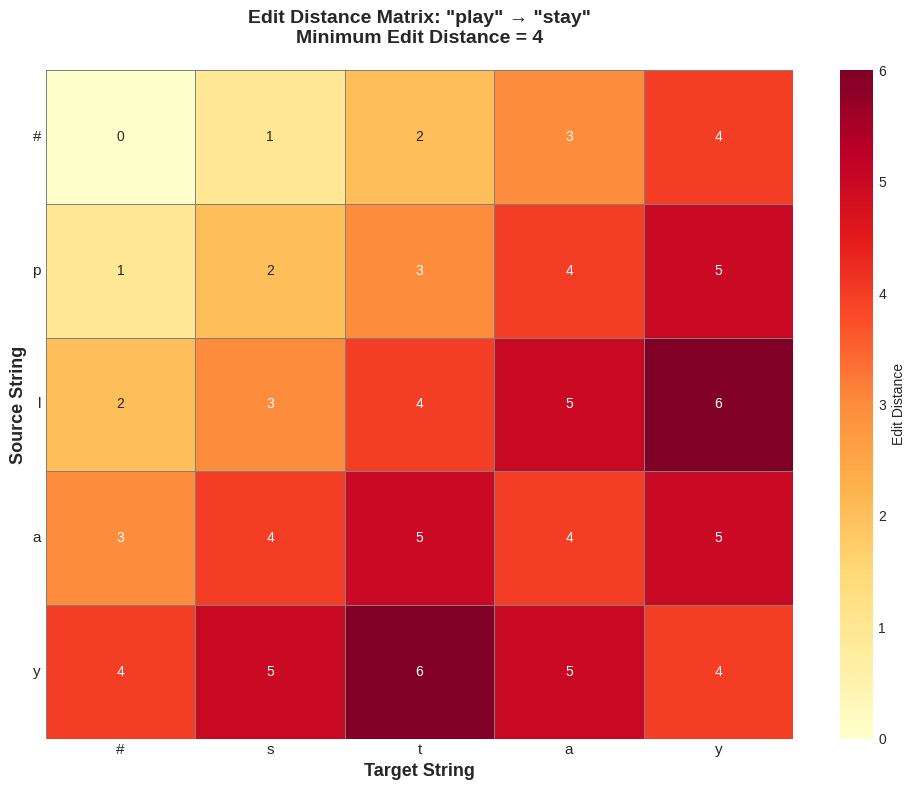


Creating visualization for 'dear' → 'deer'...


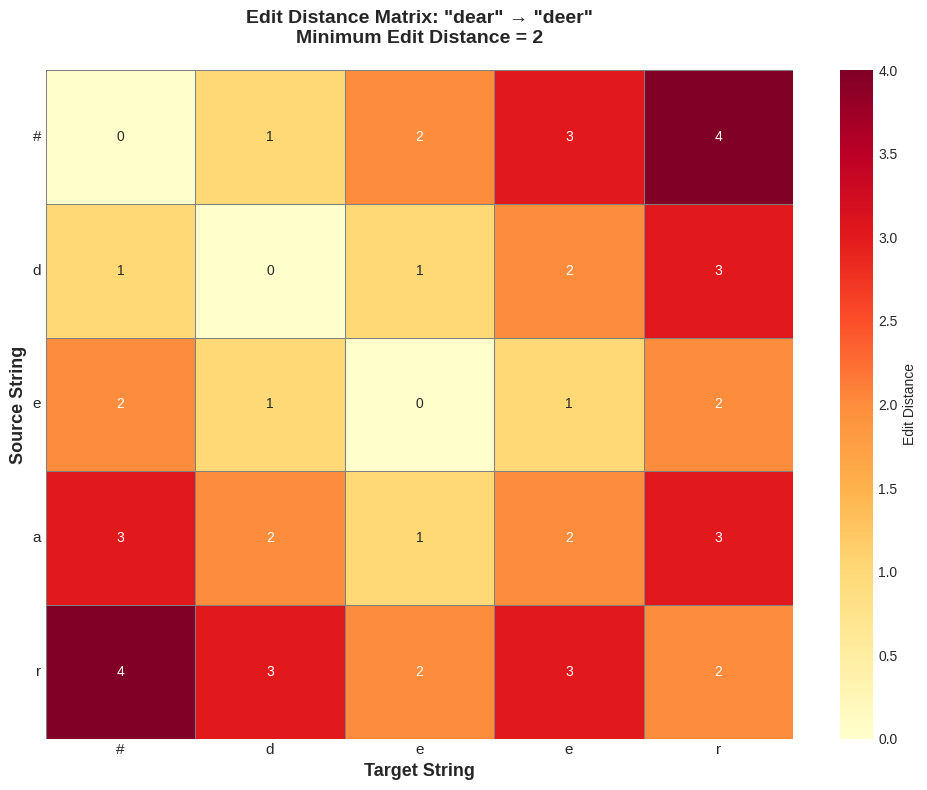

In [40]:
def visualize_edit_distance_matrix(source, target):
    """
    Create a heatmap visualization of the edit distance DP table
    """
    distance, D = min_edit_distance(source, target, verbose=False)

    # Convert to numpy array
    D_array = np.array(D)

    # Create figure
    plt.figure(figsize=(10, 8))

    # Create heatmap
    sns.heatmap(D_array, annot=True, fmt='d', cmap='YlOrRd',
                cbar_kws={'label': 'Edit Distance'},
                linewidths=0.5, linecolor='gray')

    # Set labels
    target_chars = ['#'] + list(target)
    source_chars = ['#'] + list(source)

    plt.xticks(np.arange(len(target_chars)) + 0.5, target_chars, fontsize=11)
    plt.yticks(np.arange(len(source_chars)) + 0.5, source_chars,
              rotation=0, fontsize=11)

    plt.xlabel('Target String', fontsize=13, fontweight='bold')
    plt.ylabel('Source String', fontsize=13, fontweight='bold')
    plt.title(f'Edit Distance Matrix: "{source}" → "{target}"\n' +
              f'Minimum Edit Distance = {distance}',
              fontsize=14, fontweight='bold', pad=20)

    plt.tight_layout()
    plt.savefig(f'edit_distance_{source}_{target}.png', dpi=300, bbox_inches='tight')
    plt.show()

# Visualize examples
examples = [
    ("play", "stay"),
    ("dear", "deer"),
]

print("Generating Edit Distance Visualizations:")
print("=" * 60)

for source, target in examples:
    print(f"\nCreating visualization for '{source}' → '{target}'...")
    visualize_edit_distance_matrix(source, target)


## 21. Summary and Key Takeaways

Comprehensive summary of Week 1 concepts.


In [41]:
print("=" * 70)
print("WEEK 1 SUMMARY: AUTOCORRECT AND MINIMUM EDIT DISTANCE")
print("=" * 70)

print("\n📚 CONCEPTS MASTERED:")
print("   ✓ Autocorrect system architecture")
print("   ✓ Word probability calculations")
print("   ✓ String edit operations (insert, delete, replace, switch)")
print("   ✓ Edit distance measurement")
print("   ✓ Dynamic programming approach")
print("   ✓ Levenshtein distance algorithm")
print("   ✓ Backtracing for path reconstruction")

print("\n🛠️ IMPLEMENTATION SKILLS:")
print("   ✓ Text preprocessing and tokenization")
print("   ✓ Word frequency counting")
print("   ✓ Probability distribution calculation")
print("   ✓ Edit candidate generation")
print("   ✓ DP table construction and filling")
print("   ✓ Optimal solution backtracing")

print("\n📊 KEY ALGORITHMS:")
print("   • Autocorrect Pipeline:")
print("     1. Identify misspelled word")
print("     2. Generate edit candidates (distance 1, 2)")
print("     3. Filter by vocabulary")
print("     4. Rank by probability")
print("     5. Select best correction")
print()
print("   • Minimum Edit Distance (Dynamic Programming):")
print("     D[i][j] = min(")
print("       D[i-1][j] + 1,      # delete")
print("       D[i][j-1] + 1,      # insert")
print("       D[i-1][j-1] + cost  # replace (cost=0 if match, 2 otherwise)")
print("     )")

print("\n⚡ COMPLEXITY:")
print("   • Edit Distance: O(m × n) time, O(m × n) space")
print("   • Edit-1 generation: O(26n) for word of length n")
print("   • Edit-2 generation: O(26²n²) for word of length n")
print("   • Speedup: Dynamic programming is ~millions of times")
print("     faster than brute force for typical inputs")

print("\n🎯 REAL-WORLD APPLICATIONS:")
print("   • Spell checking and correction")
print("   • Mobile keyboard predictions")
print("   • Search engine query suggestions")
print("   • DNA sequence alignment")
print("   • Plagiarism detection")
print("   • Machine translation evaluation")

print("\n💡 KEY INSIGHTS:")
print("   • Probability helps rank multiple valid corrections")
print("   • Edit distance measures string similarity")
print("   • Dynamic programming reuses subproblem solutions")
print("   • Backtrace reconstructs optimal edit sequence")
print("   • Replace costs 2 = Delete + Insert costs")

print("\n📈 COST STRUCTURE:")
print("   • Insert: 1")
print("   • Delete: 1")
print("   • Replace: 2 (equivalent to delete + insert)")
print("   • Match: 0 (characters already match)")

print("\n🔜 NEXT STEPS:")
print("   1. Complete Week 1 programming assignment")
print("   2. Experiment with different cost structures")
print("   3. Try larger vocabularies and corpora")
print("   4. Implement space-optimized DP version")
print("   5. Move on to Week 2: Part-of-Speech Tagging")

print("\n" + "=" * 70)
print("Congratulations on completing Week 1! 🎉")
print("=" * 70)


WEEK 1 SUMMARY: AUTOCORRECT AND MINIMUM EDIT DISTANCE

📚 CONCEPTS MASTERED:
   ✓ Autocorrect system architecture
   ✓ Word probability calculations
   ✓ String edit operations (insert, delete, replace, switch)
   ✓ Edit distance measurement
   ✓ Dynamic programming approach
   ✓ Levenshtein distance algorithm
   ✓ Backtracing for path reconstruction

🛠️ IMPLEMENTATION SKILLS:
   ✓ Text preprocessing and tokenization
   ✓ Word frequency counting
   ✓ Probability distribution calculation
   ✓ Edit candidate generation
   ✓ DP table construction and filling
   ✓ Optimal solution backtracing

📊 KEY ALGORITHMS:
   • Autocorrect Pipeline:
     1. Identify misspelled word
     2. Generate edit candidates (distance 1, 2)
     3. Filter by vocabulary
     4. Rank by probability
     5. Select best correction

   • Minimum Edit Distance (Dynamic Programming):
     D[i][j] = min(
       D[i-1][j] + 1,      # delete
       D[i][j-1] + 1,      # insert
       D[i-1][j-1] + cost  # replace (cost=0 i

## 22. Practice Problems

Additional exercises to reinforce learning.


In [42]:
print("Practice Problems:")
print("=" * 60)

problems = [
    {
        'title': 'Problem 1: Custom Cost Function',
        'description': 'Modify the edit distance algorithm to use custom costs: Insert=1, Delete=1, Replace=1',
        'hint': 'Change replace_cost in the min_edit_distance function'
    },
    {
        'title': 'Problem 2: Longest Common Substring',
        'description': 'Find the longest common substring between two strings using DP',
        'hint': 'Similar to edit distance, but track matches differently'
    },
    {
        'title': 'Problem 3: Context-Aware Correction',
        'description': 'Enhance autocorrect to consider the previous word when selecting correction',
        'hint': 'Use bigram probabilities: P(word2 | word1)'
    },
    {
        'title': 'Problem 4: Multiple Corrections',
        'description': 'Return top-k correction suggestions instead of just the best one',
        'hint': 'Modify get_corrections to return multiple candidates'
    },
    {
        'title': 'Problem 5: Real Word Errors',
        'description': 'Handle contextually incorrect words (e.g., "deer" when "dear" intended)',
        'hint': 'Requires language model to understand context'
    }
]

for i, problem in enumerate(problems, 1):
    print(f"\n{problem['title']}:")
    print(f"  Description: {problem['description']}")
    print(f"  Hint: {problem['hint']}")

print("\n\nTry solving these problems to deepen your understanding!")


Practice Problems:

Problem 1: Custom Cost Function:
  Description: Modify the edit distance algorithm to use custom costs: Insert=1, Delete=1, Replace=1
  Hint: Change replace_cost in the min_edit_distance function

Problem 2: Longest Common Substring:
  Description: Find the longest common substring between two strings using DP
  Hint: Similar to edit distance, but track matches differently

Problem 3: Context-Aware Correction:
  Description: Enhance autocorrect to consider the previous word when selecting correction
  Hint: Use bigram probabilities: P(word2 | word1)

Problem 4: Multiple Corrections:
  Description: Return top-k correction suggestions instead of just the best one
  Hint: Modify get_corrections to return multiple candidates

Problem 5: Real Word Errors:
  Description: Handle contextually incorrect words (e.g., "deer" when "dear" intended)
  Hint: Requires language model to understand context


Try solving these problems to deepen your understanding!


## End of Notebook

**What You've Accomplished:**

1. ✅ Built a complete autocorrect system from scratch
2. ✅ Implemented word probability calculations
3. ✅ Mastered string edit operations
4. ✅ Learned dynamic programming approach
5. ✅ Calculated minimum edit distance efficiently
6. ✅ Implemented backtracing for path reconstruction
7. ✅ Applied algorithms to real autocorrect scenarios

**Continue Your Learning:**

- Complete the Week 1 programming assignment
- Experiment with different vocabularies
- Try implementing context-aware corrections
- Explore other DP applications in NLP
- Move on to Week 2: Part-of-Speech Tagging with HMMs

Happy Learning! 🚀